Sliced Wasserstein Distance - Mean r-value: -0.03245371181040124
Jensen-Shannon Divergence - Mean r-value: 0.024249472477577205
Cosine Similarity between Gradients - Mean r-value: -0.016966285857360087
L2 Norm between Gradients - Mean r-value: -0.031659735098692354
Maximum Mean Discrepancy - Mean r-value: -0.36602555342586457
Hellinger Distance - Mean r-value: -0.029020127884949655
Frechet-Inception Distance - Mean r-value: -0.005089159296176371


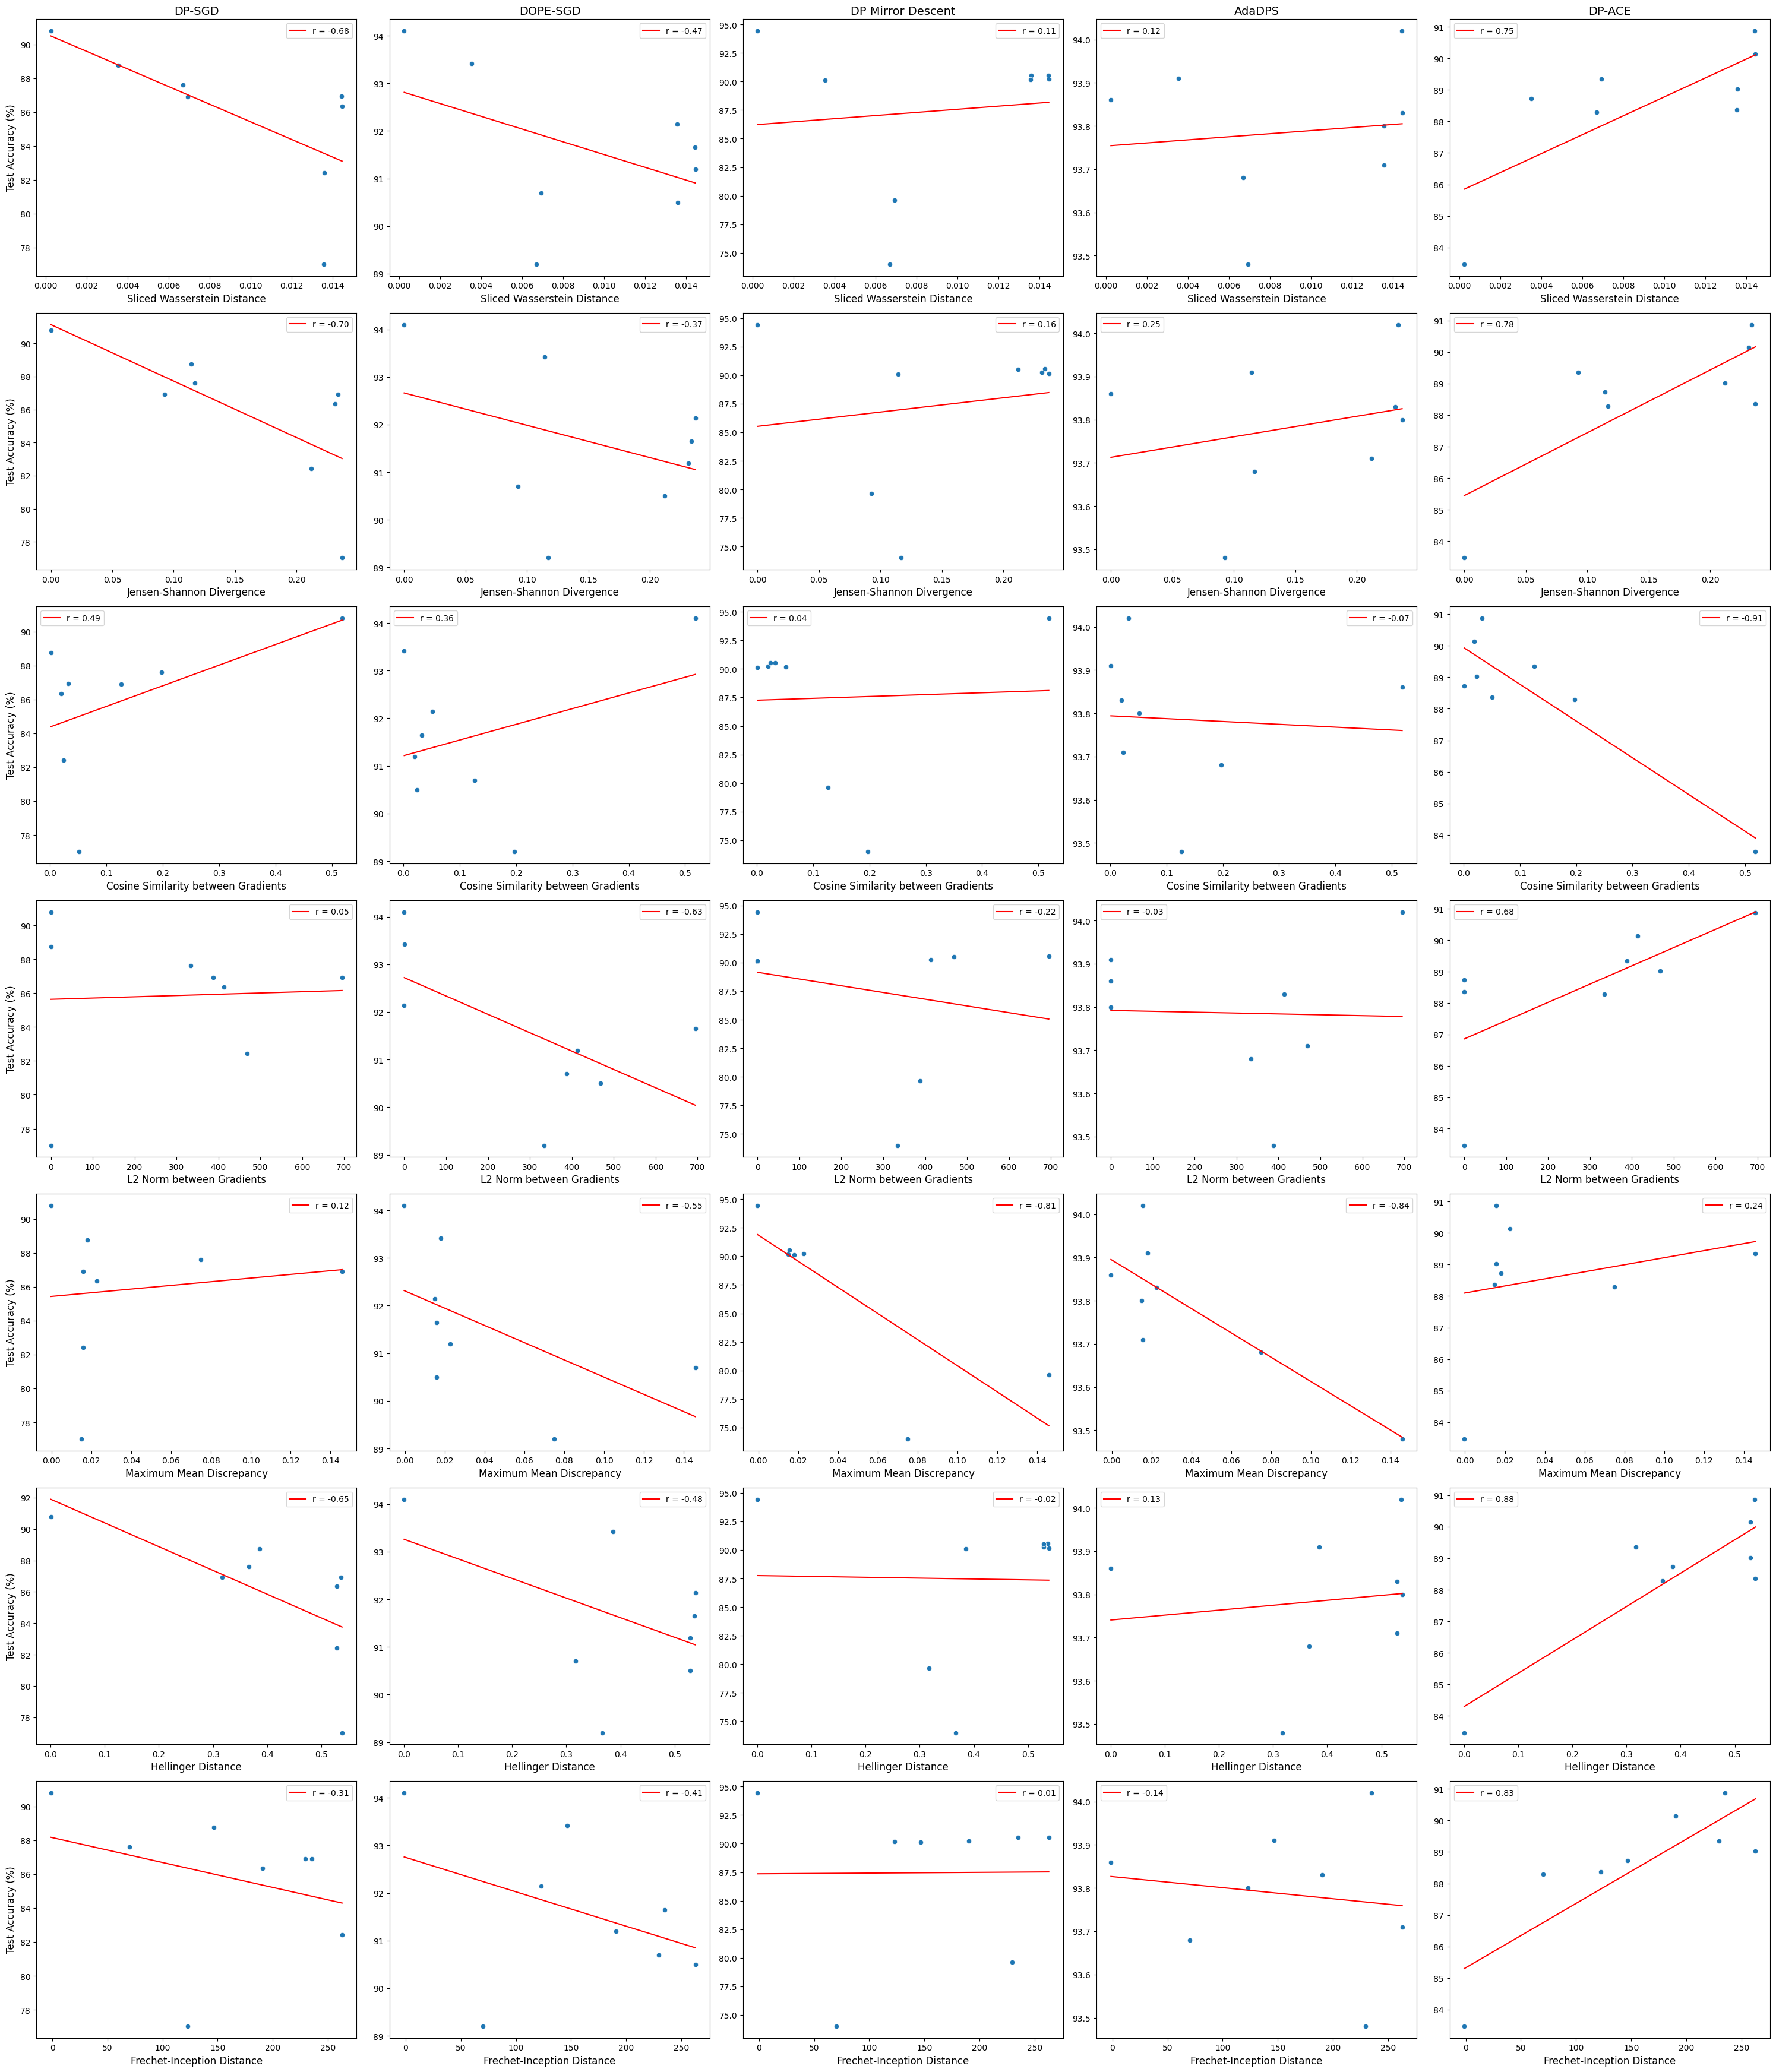

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress


order = ["USPS", "FashionMNIST", "SVHN", "CIFAR-10", "STL-10", "QMNIST", "KMNIST", "SEMEION"]


s_was_sim = [0.003530991563, 0.006940077492, 0.014461491775, 0.014432070567, 0.01358911509, 0.000248053066, 0.006706206547, 0.013562417714]
jsd_sim = [0.114499000000, 0.092713000000, 0.231467000000, 0.233652000000, 0.212181, 0.000000170178, 0.117018167721, 0.236999708724]
cosine_sim = [0.0015, 0.1261, 0.0197, 0.0326, 0.0238, 0.518260598183, 0.197512239218, 0.051266677678]
l2_norm_sim = [0.074, 388.1557, 413.0328, 695.0426, 468.1418, 0.000925271768, 334.347686767578, 0.001943506637]
mmd_sim = [0.017933581, 0.14585292, 0.022628454, 0.015758608, 0.01574812, -0.000386925530, 0.074872170000, 0.014904100000]
hellinger_sim = [0.385654985772, 0.317277278800, 0.528687696487, 0.536272981830, 0.528780144, 0.000443533919, 0.366413510639, 0.538365693953]
fid_sim = [146.760162353515, 229.598815917968, 190.478591918945, 235.153808593750, 262.777221679687, -1.3309631347625, 70.104888916016, 122.696960000000]


basic_dp_sgd = [88.75,
86.91,
86.35,
86.92,
82.43,
90.79,
87.61,
77.02,]
basic_dope_sgd = [93.42,
90.7,
91.19,
91.65,
90.5,
94.1,
89.2,
92.14]
basic_mirror_descent = [90.11,
79.64,
90.24,
90.56,
90.52,
94.44,
74.00,
90.16,]
basic_ada_dps = [93.91,
93.48,
93.83,
94.02,
93.71,
93.86,
93.68,
93.80]
dp_ace = [88.73,
89.35,
90.14,
90.87,
89.02,
83.47,
88.29,
88.36]


all_algorithms = {
   "DP-SGD": basic_dp_sgd,
   "DOPE-SGD": basic_dope_sgd,
   "DP Mirror Descent": basic_mirror_descent,
   "AdaDPS": basic_ada_dps,
   "DP-ACE": dp_ace
}


all_similarity_metrics = {
   "Sliced Wasserstein Distance": s_was_sim,
   "Jensen-Shannon Divergence": jsd_sim,
   "Cosine Similarity between Gradients": cosine_sim,
   "L2 Norm between Gradients": l2_norm_sim,
   "Maximum Mean Discrepancy": mmd_sim,
   "Hellinger Distance": hellinger_sim,
   "Frechet-Inception Distance": fid_sim,
}


k = len(all_algorithms)
n = len(all_similarity_metrics)
fig, axes = plt.subplots(nrows=n, ncols=k, figsize=(6 * k, 5 * n), squeeze=False)


for row_idx, (sim_name, sim_values) in enumerate(all_similarity_metrics.items()):
   total_r = 0
   for col_idx, (algo_name, accuracies) in enumerate(all_algorithms.items()):
      
       ax = axes[row_idx][col_idx]


       # Scatter plot
       sns.scatterplot(x=sim_values, y=accuracies, ax=ax)


       # Fit line
       slope, intercept, r_value, _, _ = linregress(sim_values, accuracies)
       total_r += r_value
       x_vals = sorted(sim_values)
       y_vals = [slope * x + intercept for x in x_vals]
       ax.plot(x_vals, y_vals, color='red', label=f'r = {r_value:.2f}')


       # Labeling
       if row_idx == 0:
           ax.set_title(f"{algo_name}", fontsize=14)
       if col_idx == 0:
           ax.set_ylabel("Test Accuracy (%)", fontsize=12)
       else:
           ax.set_ylabel("")
       ax.set_xlabel(f"{sim_name}", fontsize=12)
       ax.legend()
   print(f"{sim_name} - Mean r-value: {total_r/k}")


plt.tight_layout()
plt.show()

In [ ]:
==